In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

In [4]:
options = Options()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

In [5]:
all_products_html = []

for i in range(1, 12):
    url = f"https://www.myntra.com/products?p={i}"

    driver.get(url)
    time.sleep(3)

    products = driver.find_elements(By.CSS_SELECTOR, "li.product-base")

    for product in products:
        all_products_html.append(product.get_attribute("outerHTML"))

    print("Page", i, ":", len(products))

print("Total products:", len(all_products_html))

Page 1 : 50
Page 2 : 50
Page 3 : 50
Page 4 : 50
Page 5 : 50
Page 6 : 50
Page 7 : 50
Page 8 : 50
Page 9 : 50
Page 10 : 50
Page 11 : 50
Total products: 550


In [6]:
ratings = []

for product_html in all_products_html:
    soup = BeautifulSoup(product_html, "html.parser")
    
    rating_div = soup.find("div", class_="product-ratingsContainer")
    
    if rating_div:
        rating = rating_div.find("span").text.strip()
    else:
        rating = None
    
    ratings.append(rating)

print(ratings[:10])
print(len(ratings))

['4.5', None, '4.6', '4.4', '3.7', '4.2', '4.7', '4.4', '5', None]
550


In [7]:
reviews = []

for product_html in all_products_html:
    soup = BeautifulSoup(product_html, "html.parser")
    
    reviews_div = soup.find("div", class_="product-ratingsCount")
    
    if reviews_div:
        review = reviews_div.text.strip()
    else:
        review = None
    
    reviews.append(review)

print(reviews[:10])
print(len(reviews))

['|98k', None, '|18', '|15', '|19', '|29', '|7', '|668', '|5', None]
550


In [8]:
brands = []

for product_html in all_products_html:
    soup = BeautifulSoup(product_html, "html.parser")
    
    brand_div = soup.find("h3", class_="product-brand")
    
    if brand_div:
        brand = brand_div.text.strip()
    else:
        brand = None
    
    brands.append(brand)

print(brands[:10])
print(len(brands))

['Minimalist', 'Aurrelis', 'BIRRA', 'BIRRA', 'FLiCKA', 'BIRRA', 'BIRRA', 'OROSSENTIALS', 'BIRRA', 'BIRRA']
550


In [9]:
product_names = []

for product_html in all_products_html:
    soup = BeautifulSoup(product_html, "html.parser")
    
    product_div = soup.find("h4", class_="product-product")
    
    if product_div:
        product_name = product_div.text.strip()
    else:
        product_name = None
    
    product_names.append(product_name)

print(product_names[:10])
print(len(product_names))

['Salicylic Face Wash- - 100 ml', 'Discovery Pack (6x8) 48ml', 'Trulove EDP - 100 ml', 'Men Alden EDP - 105 ml', 'Lipstick - Twinkle Twinkle 01', 'Men Acqua Eau De Parfum- 105ml', 'Men Dark Side EDP - 105 ml', 'Small Oval Wooden Hair Brush', 'Glimpse EDP - 100 ml', 'Men Milano Max EDP - 120 ml']
550


In [10]:
prices = []

for product_html in all_products_html:
    soup = BeautifulSoup(product_html, "html.parser")
    
    price_div = soup.find("div", class_="product-price")
    
    if price_div:
        price = price_div.text.strip()
    else:
        price = None
    
    prices.append(price)

print(prices[:10])
print(len(prices))

['Rs. 284Rs. 299(5% OFF)', 'Rs. 926Rs. 2999(69% OFF)', 'Rs. 1343Rs. 1790(25% OFF)', 'Rs. 1121Rs. 1495(25% OFF)', 'Rs. 435Rs. 499(13% OFF)', 'Rs. 1343Rs. 1790(25% OFF)', 'Rs. 1348Rs. 1790(25% OFF)', 'Rs. 432Rs. 475(9% OFF)', 'Rs. 1348Rs. 1790(25% OFF)', 'Rs. 1088Rs. 1450(25% OFF)']
550


In [11]:
sizes = []

for product_html in all_products_html:
    soup = BeautifulSoup(product_html, "html.parser")
    
    size_div = soup.find("h4", class_="product-sizes")
    
    if size_div:
        size = size_div.text.strip()
    else:
        size = None
    
    sizes.append(size)

print(sizes[:10])
print(len(sizes))

['Sizes: 90-100 ML', 'Sizes: 25-50 ML', 'Sizes: 75-100 ML', 'Sizes: 100-150 ML', 'Sizes: 4-5 ML', 'Sizes: 100-150 ML', 'Sizes: 100-150 ML', 'Sizes: Onesize', 'Sizes: 75-100 ML', 'Sizes: 100-150 ML']
550


In [14]:
categories = []

for product_html in all_products_html:
    soup = BeautifulSoup(product_html, "html.parser")
    
    link = soup.find("a")["href"]
    
    category = link.split("/")[0]
    
    categories.append(category)

print(categories[:10])
print(len(categories))

['face-wash-and-cleanser', 'perfume', 'perfume', 'perfume', 'lipstick', 'perfume', 'perfume', 'hair-brush-and-comb', 'perfume', 'perfume']
550


In [13]:
print("Ratings:", len(ratings))
print("Reviews:", len(reviews))
print("Brands:", len(brands))
print("Product Names:", len(product_names))
print("Prices:", len(prices))
print("Sizes:", len(sizes))
print("Categories:", len(categories))

Ratings: 550
Reviews: 550
Brands: 550
Product Names: 550
Prices: 550
Sizes: 550
Categories: 550


In [15]:
df = pd.DataFrame({
    "Rating": ratings,
    "Reviews": reviews,
    "Brand": brands,
    "Product_Name": product_names,
    "Price": prices,
    "Size": sizes,
    "Category": categories
})

df.head()

,Rating,Reviews,Brand,Product_Name,Price,Size,Category
0,4.5,|98k,Minimalist,Salicylic Face Wash- - 100 ml,Rs. 284Rs. 299(5% OFF),Sizes: 90-100 ML,face-wash-and-cleanser
1,None,None,Aurrelis,Discovery Pack (6x8) 48ml,Rs. 926Rs. 2999(69% OFF),Sizes: 25-50 ML,perfume
2,4.6,|18,BIRRA,Trulove EDP - 100 ml,Rs. 1343Rs. 1790(25% OFF),Sizes: 75-100 ML,perfume
3,4.4,|15,BIRRA,Men Alden EDP - 105 ml,Rs. 1121Rs. 1495(25% OFF),Sizes: 100-150 ML,perfume
4,3.7,|19,FLiCKA,Lipstick - Twinkle Twinkle 01,Rs. 435Rs. 499(13% OFF),Sizes: 4-5 ML,lipstick


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rating        335 non-null    object
 1   Reviews       335 non-null    object
 2   Brand         550 non-null    object
 3   Product_Name  550 non-null    object
 4   Price         550 non-null    object
 5   Size          550 non-null    object
 6   Category      550 non-null    object
dtypes: object(7)
memory usage: 30.2+ KB


In [17]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Rating"].head(10)

0    4.5
1    NaN
2    4.6
3    4.4
4    3.7
5    4.2
6    4.7
7    4.4
8    5.0
9    NaN
Name: Rating, dtype: float64

In [18]:
df["Reviews"]=df["Reviews"].str.replace("|", "", regex=False) #regex=false bcuase | meaning is or in regex 

In [19]:
print(df["Reviews"].head(10))

0     98k
1    None
2      18
3      15
4      19
5      29
6       7
7     668
8       5
9    None
Name: Reviews, dtype: object


In [20]:
def clean_reviews(value):
    if pd.isna(value):
        return None
    
    if "k" in value:
        number = float(value.replace("k", ""))
        return int(number * 1000)
    
    return int(value)

In [21]:
print(clean_reviews("97.9k"))

97900


In [22]:
print(clean_reviews("18"))
print(clean_reviews(None))

18
None


In [23]:
df["Reviews"] = df["Reviews"].apply(clean_reviews)

print(df["Reviews"].head(10))
print(df["Reviews"].dtype)

0    98000.0
1        NaN
2       18.0
3       15.0
4       19.0
5       29.0
6        7.0
7      668.0
8        5.0
9        NaN
Name: Reviews, dtype: float64
float64


In [24]:
def clean_price(value):
    if pd.isna(value):
        return None
    
    price = re.findall(r'Rs\.\s*(\d+)', value)
    
    if price:
        return int(price[0])
    else:
        return None

In [25]:
print(clean_price("Rs. 284Rs. 299(5% OFF)"))
print(clean_price("Rs. 299"))
print(clean_price("Rs. 1343Rs. 1790(25% OFF)"))

284
299
1343


In [26]:
df["Price"] = df["Price"].apply(clean_price)

print(df["Price"].head(10))
print(df["Price"].dtype)

0     284
1     926
2    1343
3    1121
4     435
5    1343
6    1348
7     432
8    1348
9    1088
Name: Price, dtype: int64
int64


In [27]:
df["Category"] = df["Category"].str.replace("-", " ", regex=False)

print(df["Category"].head(10))

0    face wash and cleanser
1                   perfume
2                   perfume
3                   perfume
4                  lipstick
5                   perfume
6                   perfume
7       hair brush and comb
8                   perfume
9                   perfume
Name: Category, dtype: object


In [28]:
df["Brand"] = df["Brand"].str.strip()

print(df["Brand"].head(10))

0      Minimalist
1        Aurrelis
2           BIRRA
3           BIRRA
4          FLiCKA
5           BIRRA
6           BIRRA
7    OROSSENTIALS
8           BIRRA
9           BIRRA
Name: Brand, dtype: object


In [29]:
df["Product_Name"] = df["Product_Name"].str.strip()

print(df["Product_Name"].head(10))

0     Salicylic Face Wash- - 100 ml
1         Discovery Pack (6x8) 48ml
2              Trulove EDP - 100 ml
3            Men Alden EDP - 105 ml
4     Lipstick - Twinkle Twinkle 01
5    Men Acqua Eau De Parfum- 105ml
6        Men Dark Side EDP - 105 ml
7      Small Oval Wooden Hair Brush
8              Glimpse EDP - 100 ml
9       Men Milano Max EDP - 120 ml
Name: Product_Name, dtype: object


In [30]:
df.head()

,Rating,Reviews,Brand,Product_Name,Price,Size,Category
0,4.5,98000.0,Minimalist,Salicylic Face Wash- - 100 ml,284,Sizes: 90-100 ML,face wash and cleanser
1,NaN,NaN,Aurrelis,Discovery Pack (6x8) 48ml,926,Sizes: 25-50 ML,perfume
2,4.6,18.0,BIRRA,Trulove EDP - 100 ml,1343,Sizes: 75-100 ML,perfume
3,4.4,15.0,BIRRA,Men Alden EDP - 105 ml,1121,Sizes: 100-150 ML,perfume
4,3.7,19.0,FLiCKA,Lipstick - Twinkle Twinkle 01,435,Sizes: 4-5 ML,lipstick


In [31]:
df.isnull().sum()

Rating          215
Reviews         215
Brand             0
Product_Name      0
Price             0
Size              0
Category          0
dtype: int64

In [32]:
df.isnull().mean() * 100

Rating          39.090909
Reviews         39.090909
Brand            0.000000
Product_Name     0.000000
Price            0.000000
Size             0.000000
Category         0.000000
dtype: float64

In [33]:
print(df.shape)

(550, 7)


In [34]:
df.dtypes

Rating          float64
Reviews         float64
Brand            object
Product_Name     object
Price             int64
Size             object
Category         object
dtype: object

In [35]:
df.describe()

,Rating,Reviews,Price
count,335.000000,335.000000,550.000000
mean,4.340597,11304.552239,706.694545
std,0.325870,27971.610276,856.747259
min,3.200000,5.000000,125.000000
25%,4.300000,29.000000,284.000000
50%,4.500000,617.000000,435.000000
75%,4.500000,6800.000000,750.000000
max,5.000000,230400.000000,7304.000000


In [21]:
import re

df["Size"] = df["Size"].apply(
    lambda x: re.sub(r"Sizes:\s*", "", x)
)

df["Size"].head()

0     90-100 ML
1      25-50 ML
2     75-100 ML
3    100-150 ML
4        4-5 ML
Name: Size, dtype: object

In [22]:
df.to_csv("myntra_products.csv", index=False)

print("File saved successfully")

File saved successfully


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("myntra_products.csv")

print(df.shape)
df.head()

(550, 7)


,Rating,Reviews,Brand,Product_Name,Price,Size,Category
0,4.5,98000.0,Minimalist,Salicylic Face Wash- - 100 ml,284,90-100 ML,face wash and cleanser
1,NaN,NaN,Aurrelis,Discovery Pack (6x8) 48ml,926,25-50 ML,perfume
2,4.6,18.0,BIRRA,Trulove EDP - 100 ml,1343,75-100 ML,perfume
3,4.4,15.0,BIRRA,Men Alden EDP - 105 ml,1121,100-150 ML,perfume
4,3.7,19.0,FLiCKA,Lipstick - Twinkle Twinkle 01,435,4-5 ML,lipstick


In [3]:
df.head()

,Rating,Reviews,Brand,Product_Name,Price,Size,Category
0,4.5,98000.0,Minimalist,Salicylic Face Wash- - 100 ml,284,90-100 ML,face wash and cleanser
1,NaN,NaN,Aurrelis,Discovery Pack (6x8) 48ml,926,25-50 ML,perfume
2,4.6,18.0,BIRRA,Trulove EDP - 100 ml,1343,75-100 ML,perfume
3,4.4,15.0,BIRRA,Men Alden EDP - 105 ml,1121,100-150 ML,perfume
4,3.7,19.0,FLiCKA,Lipstick - Twinkle Twinkle 01,435,4-5 ML,lipstick


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rating        335 non-null    float64
 1   Reviews       335 non-null    float64
 2   Brand         550 non-null    object 
 3   Product_Name  550 non-null    object 
 4   Price         550 non-null    int64  
 5   Size          550 non-null    object 
 6   Category      550 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 30.2+ KB


In [7]:
df[df["Rating"].isna()]

,Rating,Reviews,Brand,Product_Name,Price,Size,Category
1,NaN,NaN,Aurrelis,Discovery Pack (6x8) 48ml,926,Sizes: 25-50 ML,perfume
9,NaN,NaN,BIRRA,Men Milano Max EDP - 120 ml,1088,Sizes: 100-150 ML,perfume
11,NaN,NaN,Bhartiye Products,Structured Handheld Bag,750,Sizes: Onesize,handbags
14,NaN,NaN,THE 9192,Hair Oil Gel & Spider Wax,1161,Sizes: Pack,hair gels and wax
23,NaN,NaN,THE 9192,Spider Wax & Mix Fruit Gel,738,Sizes: Pack,hair gels and wax
...,...,...,...,...,...,...,...
536,NaN,NaN,NatureNova Herbals,Softening & Shining Fruit Conditioner 115 ml,235,Sizes: 100-150 ML,conditioner
540,NaN,NaN,THE SOUMI'S CAN PRODUCT,2Pc Anti Wrinkle Serums,228,Sizes: 150-200 ML,serum and gel
542,NaN,NaN,THE SOUMI'S CAN PRODUCT,2pc Milk Mask&AntiWrinkleCream,450,Sizes: 90-100 ML,skin care combo
543,NaN,NaN,THE SOUMI'S CAN PRODUCT,Scrubber & Moisturizing Cream,391,Sizes: 90-100 ML,skin care combo


In [5]:
df.duplicated().sum()

np.int64(303)

In [6]:
df.isnull().sum()

Rating          215
Reviews         215
Brand             0
Product_Name      0
Price             0
Size              0
Category          0
dtype: int64

In [7]:
df["Price"].head()

0     284
1     926
2    1343
3    1121
4     435
Name: Price, dtype: int64

In [8]:
df["Reviews"].head(10)

0    98000.0
1        NaN
2       18.0
3       15.0
4       19.0
5       29.0
6        7.0
7      668.0
8        5.0
9        NaN
Name: Reviews, dtype: float64

In [9]:
df["Rating"].head(10)

0    4.5
1    NaN
2    4.6
3    4.4
4    3.7
5    4.2
6    4.7
7    4.4
8    5.0
9    NaN
Name: Rating, dtype: float64

In [10]:
df[["Brand", "Product_Name", "Size", "Category"]].head()

,Brand,Product_Name,Size,Category
0,Minimalist,Salicylic Face Wash- - 100 ml,Sizes: 90-100 ML,face wash and cleanser
1,Aurrelis,Discovery Pack (6x8) 48ml,Sizes: 25-50 ML,perfume
2,BIRRA,Trulove EDP - 100 ml,Sizes: 75-100 ML,perfume
3,BIRRA,Men Alden EDP - 105 ml,Sizes: 100-150 ML,perfume
4,FLiCKA,Lipstick - Twinkle Twinkle 01,Sizes: 4-5 ML,lipstick


In [13]:
df["Category"].unique()

array(['face wash and cleanser', 'perfume', 'lipstick',
       'hair brush and comb', 'handbags', 'facial kit',
       'hair gels and wax', 'massage oils', 'blush', 'serum and gel',
       'tea set', 'mask and peel', 'skin care combo', 'toner',
       'hair serum', 'soap', 'face sunscreen', 'skin care gift set',
       'hair care combo', 'body wax and essentials', 'tops',
       'body sunscreen', 'night cream', 'nail polish',
       'face scrub and exfoliator', 'day cream', 'body cream and lotion',
       'sarees', 'nightdress', 'shawl', 'attar', 'shampoo', 'hair colour',
       'compact', 'conditioner', 'appliance covers', 'mascara',
       'lip balm', 'face mist', 'cushion covers', 'hair oil',
       'facial oil', 'bath and body combo', 'body scrub and exfoliator',
       'body wash and shower gel', 'hair care gift set', 'hair masks'],
      dtype=object)

In [14]:
df["Brand"] = df["Brand"].str.strip()
df["Product_Name"] = df["Product_Name"].str.strip()
df["Category"] = df["Category"].str.strip()

In [15]:
df.dtypes

Rating          float64
Reviews         float64
Brand            object
Product_Name     object
Price             int64
Size             object
Category         object
dtype: object

In [16]:
df.isnull().sum()

Rating          215
Reviews         215
Brand             0
Product_Name      0
Price             0
Size              0
Category          0
dtype: int64

In [19]:
df["Category"].value_counts().head(10)

Category
face wash and cleanser    98
lipstick                  50
tops                      39
perfume                   38
serum and gel             36
massage oils              29
mask and peel             23
skin care combo           22
toner                     20
shawl                     16
Name: count, dtype: int64

In [20]:
df["Brand"].value_counts().head(10)

Brand
ZAROON PRODUCTION          39
Minimalist                 26
BIRRA                      24
Renee                      22
Radhe Products             16
PERPAA                     16
THE SOUMI'S CAN PRODUCT    15
Thalgo                     13
TNW the natural wash       12
Ponds                      12
Name: count, dtype: int64

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,335.0,4.340597,0.325870,3.2,4.3,4.5,4.5,5.0
Reviews,335.0,11304.552239,27971.610276,5.0,29.0,617.0,6800.0,230400.0
Price,550.0,706.694545,856.747259,125.0,284.0,435.0,750.0,7304.0


# Interpretation:
  
    Rating: Average rating is 4.34.
    Reviews: Average reviews are 11,304. Some products have very high reviews.
    Price: Average price is ₹707.
    Minimum price: ₹125.
    Maximum price: ₹7,304.
    Median price: ₹435, which is lower than the average price. This means some high-priced products increase the average.

# Univariate Analysis

# numerical Columns

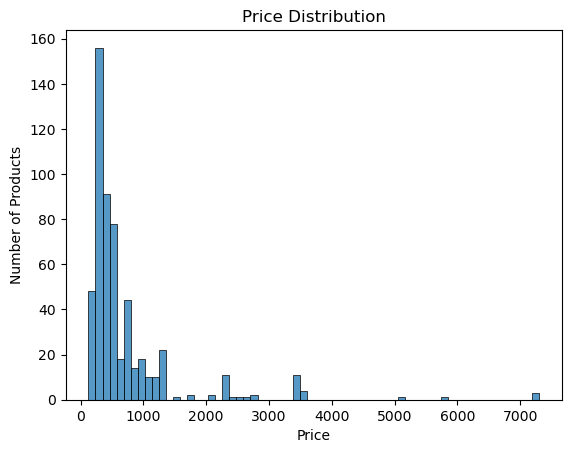

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Price"])

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

The price distribution is right-skewed, which means most products have lower prices.

Most products are priced below ₹1,000.

A small number of products have very high prices, reaching above ₹5,000. These can be considered high-price values/outliers.

# Rating - Histogram & KDE

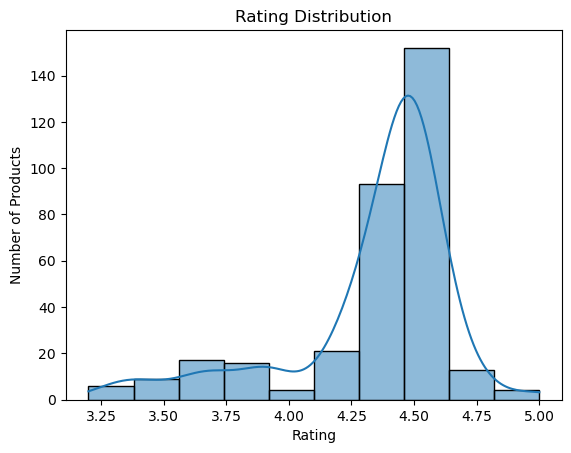

In [7]:
sns.histplot(df["Rating"].dropna(), bins=10,kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()

Most products have ratings between 4.25 and 4.60, with 4.5 being the most common range. Overall, the products have relatively high ratings.

# Reviews Distribution - Box plot

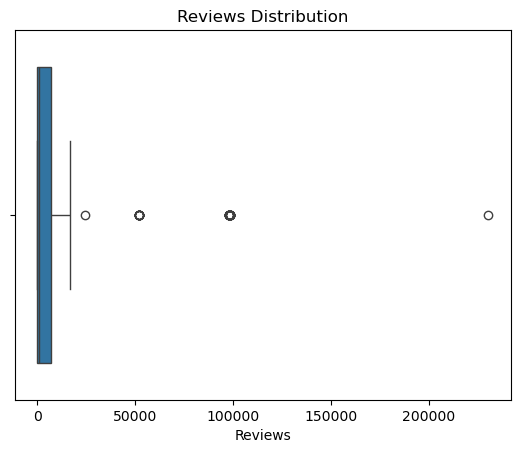

In [34]:
sns.boxplot(x=df["Reviews"])

plt.title("Reviews Distribution")
plt.xlabel("Reviews")
plt.show()

Most products have a relatively low number of reviews. A few products have very high review counts, which appear as outliers.
The points around 25,000, 50,000, 100,000 and 230,000 are the very high review values.

# Category distribution - Countplot

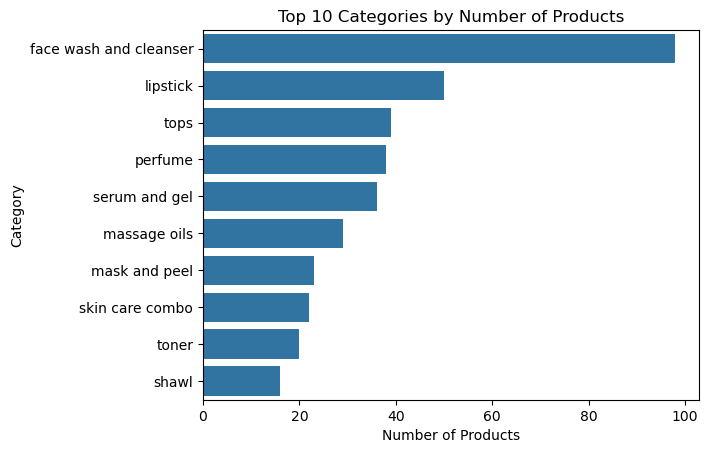

In [35]:
sns.countplot(y=df["Category"], order=df["Category"].value_counts().head(10).index)

plt.title("Top 10 Categories by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()

Face wash and cleanser has the highest number of products (98). Lipstick is the second highest with 50 products. Tops and perfume also have many products. Shawl has the lowest count among the top 10 categories.

# Top 10 Brands -Countplot

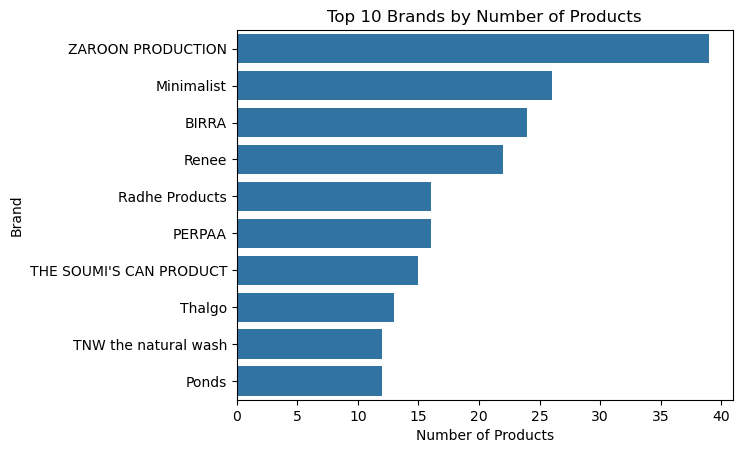

In [36]:
sns.countplot(y=df["Brand"], order=df["Brand"].value_counts().head(10).index)

plt.title("Top 10 Brands by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.show()

ZAROON PRODUCTION has the highest number of products with 39. Minimalist has 26 products, followed by BIRRA with 24. The other brands have fewer products compared with the top brands.

# Rating count

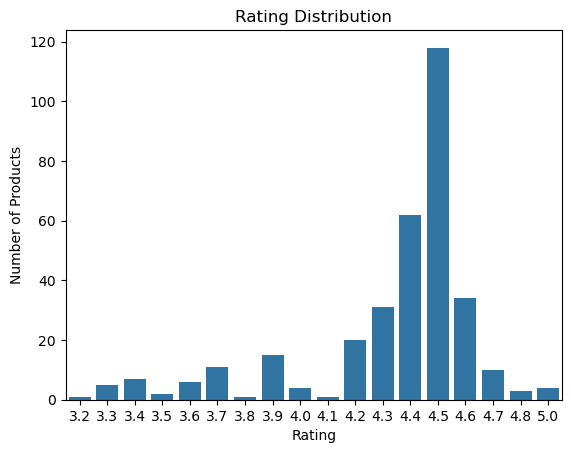

In [37]:
sns.countplot(x=df["Rating"])

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()

Most products have ratings between 4.3 and 4.6. A rating of 4.5 has the highest number of products. Very few products have ratings below 3.5 or close to 5.0.

# Bivariate Analysis

# Price vs Rating

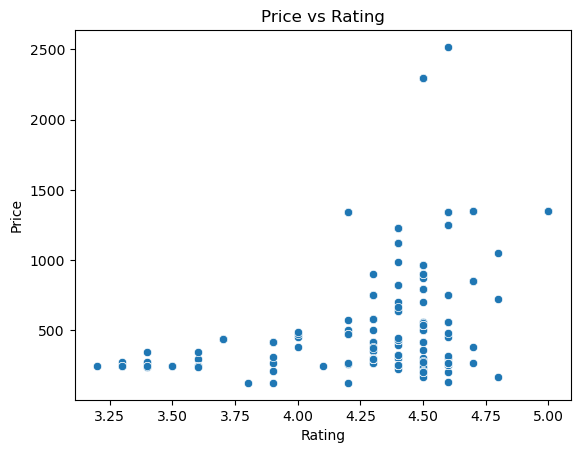

In [38]:
sns.scatterplot(data=df, x="Rating", y="Price")
plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

There is no clear relationship between Price and Rating. Products with similar ratings have different prices. Some high-priced products have high ratings, but high ratings do not always mean higher prices.

# Price by Category

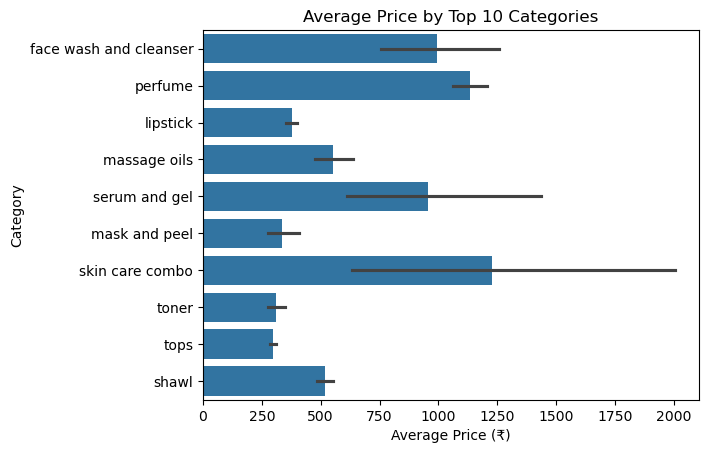

In [46]:
df_top = df[df["Category"].isin(
    df["Category"].value_counts().head(10).index
)]  # Take only products belonging to the top 10 categories

sns.barplot(data=df_top, y="Category", x="Price")

plt.title("Average Price by Top 10 Categories")
plt.xlabel("Average Price (₹)")
plt.ylabel("Category")
plt.show()

Skin care combo has the highest average price among the top 10 categories, while lipstick has the lowest average price. Perfume and face wash also have relatively high average prices.

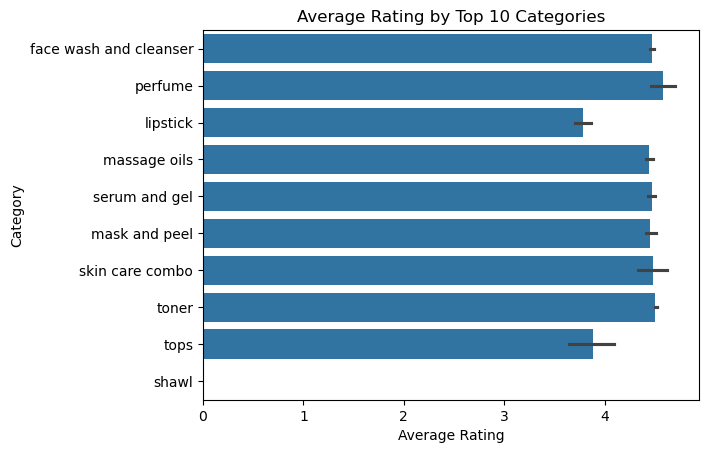

In [49]:
df_top = df[df["Category"].isin(
    df["Category"].value_counts().head(10).index
)]
sns.barplot(data=df_top, y="Category", x="Rating")

plt.title("Average Rating by Top 10 Categories")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.show()

Most top categories have average ratings above 4.0. Perfume has the highest average rating, while lipstick and tops have relatively lower average ratings. Overall, the ratings are quite high across these categories.

# Price vs Reviews

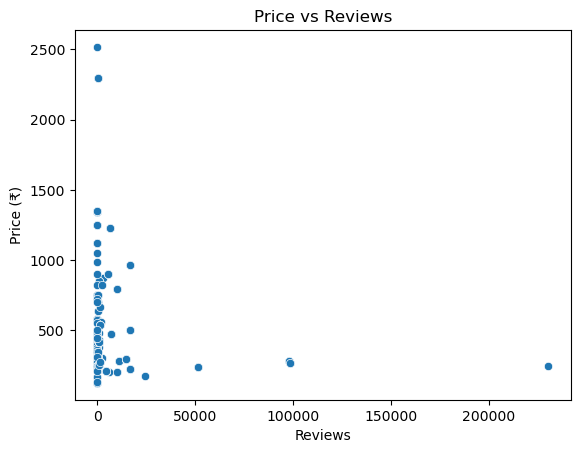

In [50]:
sns.scatterplot(data=df, x="Reviews", y="Price")

plt.title("Price vs Reviews")
plt.xlabel("Reviews")
plt.ylabel("Price (₹)")
plt.show()

Most products have a small number of reviews, while only a few products have very high review counts. There is no clear relationship between price and number of reviews.

# Price by Rating

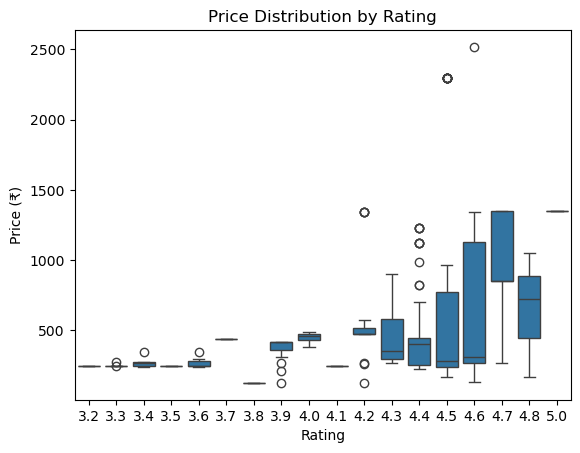

In [51]:
sns.boxplot(data=df, x="Rating", y="Price") #dl!

plt.title("Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price (₹)")
plt.show()

Prices vary widely across different ratings. Higher-rated products do not always have higher prices. Some rating groups also contain high-priced outliers.

# Average Reviews by Rating

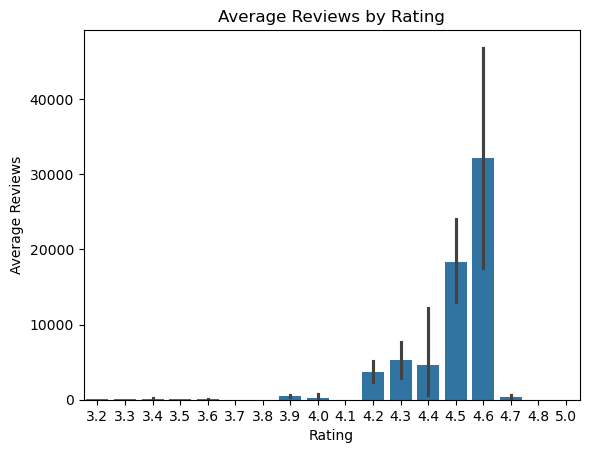

In [54]:
sns.barplot(data=df, x="Rating", y="Reviews")

plt.title("Average Reviews by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Reviews")
plt.show()

Rating 4.6 has the highest average number of reviews.
Rating 4.5 also has a high average number of reviews.
Ratings around 4.2–4.4 have lower average reviews.
Ratings below 4.1 have very few average reviews.
So, in this dataset, products with ratings around 4.5–4.6 have the highest average reviews.

# Top 5 Categories Distribution

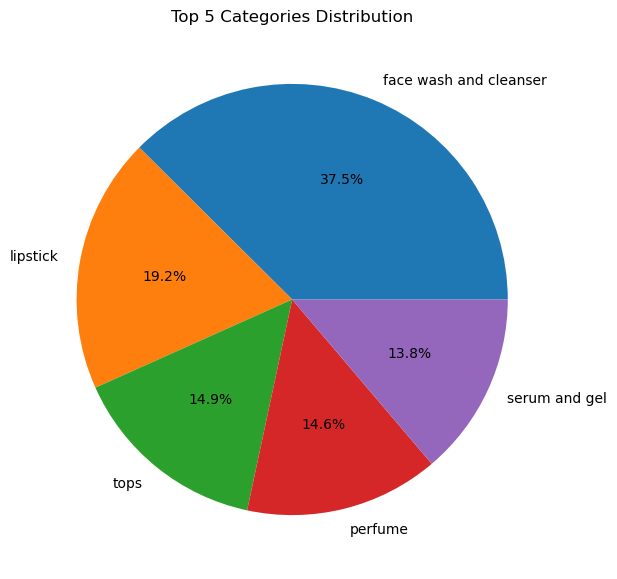

In [62]:
top5 = df["Category"].value_counts().head(5)

plt.figure(figsize=(7,7))

plt.pie(top5, labels=top5.index, autopct="%1.1f%%")

plt.title("Top 5 Categories Distribution")
plt.show()

# Correlation Heatmap

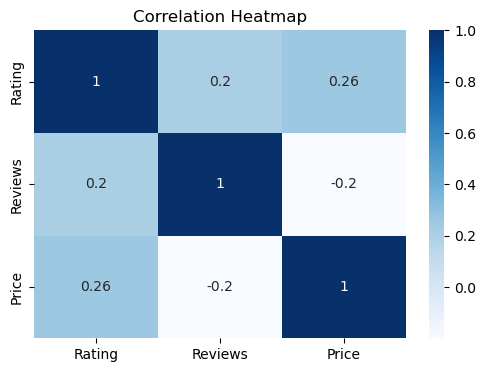

In [61]:
plt.figure(figsize=(6,4))

correlation = df[["Rating", "Reviews", "Price"]].corr()

sns.heatmap(correlation, annot=True, cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

There is no strong relationship between Rating, Reviews, and Price.

# Hypothesis Testing

In [8]:
import scipy.stats as st

# Category vs Price

In [9]:
groups = [df[df["Category"] == category]["Price"]
          for category in df["Category"].unique()] # Category → separate groups

In [10]:
stat, p_value = st.f_oneway(*groups)

print("f_value:", stat)
print("p_value:", p_value)
alpha = 0.05

if p_value <= alpha:
    print("Reject Null Hypothesis i.e. There is a significant difference in average price across categories.")
else:
    print("Failed to Reject Null Hypothesis i.e. There is no significant difference in average price across categories.")

f_value: 3.8193394202456448
p_value: 4.726420556058431e-14
Reject Null Hypothesis i.e. There is a significant difference in average price across categories.


# Category vs Rating

In [69]:
groups = [df[df["Category"] == category]["Rating"].dropna()
          for category in df["Category"].unique()]

stat, p_value = st.f_oneway(*groups)
print("f_value:", stat)
print("p_value:", p_value)


f_value: nan
p_value: nan


C:\Users\teja\AppData\Local\Temp\ipykernel_16748\4293863220.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = st.f_oneway(*groups)


In [11]:
groups = [df[df["Category"] == category]["Rating"].dropna()
          for category in df["Category"].unique()
          if df[df["Category"] == category]["Rating"].dropna().shape[0] >= 2]

stat, p_value = st.f_oneway(*groups)
print("f_value:", stat)
print("p_value:", p_value)
alpha = 0.05

if p_value <= alpha:
    print("Reject Null Hypothesis i.e. There is a significant difference in average rating across categories.")
else:
    print("Failed to Reject Null Hypothesis i.e. There is no significant difference in average rating across categories.")

f_value: 30.327160203161338
p_value: 3.6686354015359713e-65
Reject Null Hypothesis i.e. There is a significant difference in average rating across categories.


# Price vs Rating

In [72]:
from scipy.stats import pearsonr

data = df[["Price", "Rating"]].dropna()

correlation, p_value = pearsonr(data["Price"], data["Rating"])

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.2569020608396949
P-value: 1.8912553688636292e-06


In [ ]:
# When price increases, rating tends to increase slightly, but the relationship is weak.

In [74]:
alpha = 0.05

if p_value <= alpha:
    print("Reject Null Hypothesis i.e. There is a significant relationship between Price and Rating.")
else:
    print("Failed to Reject Null Hypothesis i.e. There is no significant relationship between Price and Rating.")

Reject Null Hypothesis i.e. There is a significant relationship between Price and Rating.


# What I Observed
    Most products are priced below ₹1,000.
    Face wash and cleanser has the highest number of products.
    Most products have ratings around 4.3–4.6.
    A few products have very high review counts.
    Some products have high prices but this does not always mean higher ratings.
    ZAROON PRODUCTION has the highest number of products in the dataset.

# Interpretation
   Product prices are different across categories.

   Different categories have different average ratings.
       
   Price and rating have a weak positive relationship.
       
   Products with more reviews do not always have higher prices.
       
   A few expensive products increase the overall average price.

# Business Insights:
   ### For Customers
             Customers can compare products by price, rating, and reviews instead of looking only at price

             Highly rated products are available at different price levels.
                 
   ### For Sellers/Brands
                 Understanding category-level pricing and ratings can help with product positioning.
                 Review counts can help identify products with stronger customer engagement.
                

# Final Conclusion

The analysis shows that product categories, prices, ratings, and reviews are different in the Myntra dataset. Different categories have different average prices and ratings. Price and rating have a statistically significant but weak positive relationship. Overall, price alone does not decide a product's rating or number of reviews.

# My Suggestions

Customers should check the price, rating, and reviews before buying.

Customers should compare similar products before buying.

Myntra can use ratings and reviews to understand customer preferences.